
# MOQA for Call-Center Staffing (Cost + SLA + ASA)

**Multi-Objective Quantum Approximation (MOQA)** maps several objectives to a hierarchy of tractable Hamiltonians:

$$
h_{\max}(b)=\max\{h_1(b),\ldots,h_M(b)\}
\quad\approx\quad
h_{(p)}(b)=\Big(\sum_{m=1}^{M} h_m(b)^p\Big)^{1/p}
$$

with sandwich bounds independent of problem size \(n\).

This notebook applies MOQA to **workforce staffing**:

| Objective | Meaning |
|-----------|---------|
| \(h_{\mathrm{cost}}\) | Labor cost |
| \(h_{\mathrm{SLA}}\) | Soft shortfall vs Erlang \(R^{\mathrm{SLA}}\) |
| \(h_{\mathrm{ASA}}\) | Soft shortfall vs Erlang \(R^{\mathrm{ASA}}\) |

We build \(M=3\) QUBOs, compute \(h_{\max}\) and \(h_{(p)}\) for \(p=1..8\), plot the landscapes, and evaluate true SLA / ASA of recovered plans.


## 1. Setup

In [1]:

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from math import exp
from itertools import product
import time, json, os

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.random.seed(3)

TARGET_SL = 0.80
TARGET_ASA = 25.0
AHT, ISEC = 300.0, 1800.0
N_SHIFTS, NMAX = 3, 2
COVER = np.zeros((N_SHIFTS, 8), dtype=int)
COVER[0, 0:5] = 1
COVER[1, 2:7] = 1
COVER[2, 4:8] = 1
SHIFT_COST = np.array([1.0, 1.05, 1.1])
SHIFT_NAMES = ["Early", "Mid", "Late"]
print(f"Targets: SLA≥{TARGET_SL:.0%}, ASA≤{TARGET_ASA:.0f}s | qubits={N_SHIFTS*NMAX}")


Targets: SLA≥80%, ASA≤25s | qubits=6


## 2. Erlang metrics & demand

In [2]:

def erlang_c(n, A):
    if n <= 0 or n <= A: return 1.0
    try:
        rho = A / n; B = 1.0
        for k in range(1, n+1): B = 1.0 + (k/A)*B
        return 1.0/(1.0+(1.0-rho)*(B-1.0)/rho) if rho > 0 else 0.0
    except Exception:
        return 1.0

def service_level(n, arr, tau=20.0):
    if arr <= 0: return 1.0
    if n <= 0: return 0.0
    A = (arr/ISEC)*AHT
    if n <= A: return 0.0
    pw = erlang_c(n, A)
    return float(max(0, min(1, 1 - pw*exp(-(n-A)*tau/AHT))))

def asa_seconds(n, arr):
    if arr <= 0: return 0.0
    if n <= 0: return 999.0
    A = (arr/ISEC)*AHT
    if n <= A: return 999.0
    return float(erlang_c(n, A)*AHT/(n-A))

def required_agents(arr, target_sl=None, target_asa=None, max_n=30):
    if arr <= 0: return 0
    n = max(1, int(np.ceil(arr*AHT/ISEC)))
    while n <= max_n:
        ok1 = True if target_sl is None else service_level(n, arr) >= target_sl - 1e-6
        ok2 = True if target_asa is None else asa_seconds(n, arr) <= target_asa + 1e-6
        if ok1 and ok2: return n
        n += 1
    return max_n

def make_demand(seed=3):
    rng = np.random.default_rng(seed)
    base = np.array([4, 7, 11, 14, 12, 10, 8, 5], dtype=float)
    return np.maximum(1, np.round(base*rng.uniform(0.9, 1.1, 8))).astype(int)

demand = make_demand(3)
R_sla = np.array([required_agents(a, target_sl=TARGET_SL) for a in demand])
R_asa = np.array([required_agents(a, target_asa=TARGET_ASA) for a in demand])
print("Demand:", demand.tolist())
print("R_SLA: ", R_sla.tolist())
print("R_ASA: ", R_asa.tolist())


Demand: [4, 7, 12, 14, 11, 10, 8, 5]
R_SLA:  [2, 3, 4, 4, 4, 3, 3, 2]
R_ASA:  [2, 3, 4, 5, 4, 4, 3, 3]


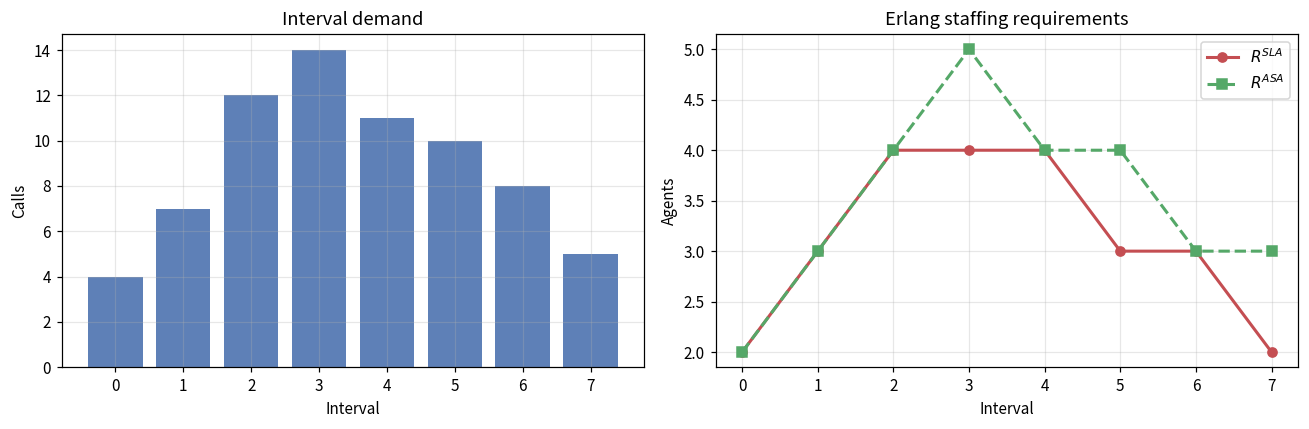

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(demand))
axes[0].bar(x, demand, color="#4C72B0", alpha=0.9)
axes[0].set_title("Interval demand"); axes[0].set_xlabel("Interval"); axes[0].set_ylabel("Calls")
axes[1].plot(x, R_sla, "o-", color="#C44E52", lw=2, label=r"$R^{SLA}$")
axes[1].plot(x, R_asa, "s--", color="#55A868", lw=2, label=r"$R^{ASA}$")
axes[1].set_title("Erlang staffing requirements"); axes[1].set_xlabel("Interval")
axes[1].set_ylabel("Agents"); axes[1].legend()
plt.tight_layout(); plt.show()



## 3. MOQA utilities (QUBO → Ising, \(M\)-QUBOs, \(h_{(p)}\))


In [4]:

def index_to_s(index, bits):
    return tuple(1 if b == "0" else -1 for b in format(index, f"0{bits}b"))

def create_z_array(size):
    z = np.array([1.0, -1.0])
    out = []
    for i in range(size):
        v = np.ones(2**i)
        v = np.kron(v, z)
        v = np.kron(v, np.ones(2**(size-i-1)))
        out.append(v)
    return out

class QUBO:
    def __init__(self, A, a, alpha):
        self.A = np.asarray(A, float)
        self.a = np.asarray(a, float)
        self.alpha = float(alpha)
        self.size = len(self.a)
    def calculate_cost(self, s):
        s = np.asarray(s, float)
        return float(s.T @ self.A @ s + self.a.T @ s + self.alpha)
    def qubo_to_ising(self):
        size = self.size
        z_array = create_z_array(size)
        H = np.ones(2**size) * self.alpha
        for i in range(size):
            H += self.a[i] * z_array[i]
            for j in range(size):
                H += self.A[i, j] * (z_array[i] * z_array[j])
        self.H = H
        self.best_index = int(np.argmin(H))
        self.best_s = index_to_s(self.best_index, size)
        self.min_cost = float(np.min(H))

def get_shift(qubo_list, version=4):
    shift = -np.inf
    for qubo in qubo_list:
        A_tilde = np.vstack((qubo.A, 0.5*qubo.a))
        col = np.hstack((0.5*qubo.a, 0)).reshape(-1, 1)
        A_tilde = np.hstack((A_tilde, col))
        temp = -(len(qubo.a)+1)*np.linalg.eigvalsh(A_tilde).min() - qubo.alpha
        shift = max(shift, float(temp))
    return shift

class M_QUBOs:
    def __init__(self, qubos_list):
        self.qubos_list = qubos_list
        self.shift = get_shift(qubos_list)
        self.ising_list = []
        for q in qubos_list:
            if not hasattr(q, "H"):
                q.qubo_to_ising()
            self.ising_list.append(q.H + self.shift)
        self.ising_list = np.array(self.ising_list)
        self.size = qubos_list[0].size
        self.M = len(qubos_list)
        self.ising_size = self.ising_list.shape[1]
        self.h_max = self._one(np.inf)
        self.h_p_list = []
    def _one(self, p):
        h_p = np.linalg.norm(self.ising_list, axis=0, ord=p)
        h_sort = np.sort(h_p)
        arg = int(np.argmin(h_p))
        return (h_p, float(h_sort[0]), arg, index_to_s(arg, self.size),
                (float(h_sort[0]), float(h_sort[1]), float(h_sort[-1])))
    def calculate_h_p(self, p_max, p_min=1):
        self.h_p_list = [self._one(p) for p in range(p_min, p_max+1)]

print("MOQA utils ready")


MOQA utils ready



## 4. Staffing QUBOs: cost, SLA shortfall, ASA shortfall

Unary encoding \(n_s=\sum_k x_{s,k}\). Shortfall objectives use
\((\sum_s C_{s,t}n_s - R_t)^2\) so low coverage is expensive.


In [5]:

def spins_to_n(s):
    bits = [(1 - int(si))//2 for si in s]  # +1→0, -1→1
    n = np.zeros(N_SHIFTS, dtype=int)
    for sh in range(N_SHIFTS):
        n[sh] = sum(bits[sh*NMAX:(sh+1)*NMAX])
    return n

def coverage(n):
    return COVER.T @ np.asarray(n)

def evaluate_n(n, demand, R_sla, R_asa):
    n = np.asarray(n, dtype=int)
    cov = coverage(n)
    cost = float(np.dot(SHIFT_COST, n))
    sls, asas, calls = [], [], []
    for t, arr in enumerate(demand):
        a = int(cov[t])
        sls.append(service_level(a, int(arr)))
        asas.append(asa_seconds(a, int(arr)))
        calls.append(int(arr))
    w = np.maximum(np.array(calls, float), 1e-6)
    sla = float(np.average(sls, weights=w))
    asa = float(np.average(asas, weights=w))
    return dict(
        n=n.tolist(), cost=cost, sla=sla, asa=asa,
        short_sla=float(np.sum(np.maximum(0, R_sla-cov))),
        short_asa=float(np.sum(np.maximum(0, R_asa-cov))),
        meets_sla=sla >= TARGET_SL-1e-3,
        meets_asa=asa <= TARGET_ASA+1e-3,
        meets_both=(sla >= TARGET_SL-1e-3) and (asa <= TARGET_ASA+1e-3),
        agents=int(n.sum()), coverage=cov.tolist(),
        interval_sla=sls, interval_asa=asas,
    )

def binary_qubo_to_ising_params(Qdict, n_vars):
    A = np.zeros((n_vars, n_vars))
    a = np.zeros(n_vars)
    alpha = 0.0
    for (i, j), q in Qdict.items():
        if i == j:
            alpha += q/2; a[i] -= q/2
        else:
            alpha += q/4; a[i] -= q/4; a[j] -= q/4
            A[i, j] += q/8; A[j, i] += q/8
    return A, a, alpha

def build_staffing_qubos(demand, R_sla, R_asa, w_cost=5.0, w_sla=25.0, w_asa=12.0):
    n_vars = N_SHIFTS * NMAX
    n_int = len(demand)
    def idx(s, k): return s*NMAX + k

    Qc = {}
    for s in range(N_SHIFTS):
        for k in range(NMAX):
            Qc[(idx(s,k), idx(s,k))] = Qc.get((idx(s,k), idx(s,k)), 0) + w_cost*float(SHIFT_COST[s])

    def shortfall_Q(R, w):
        Q = {}
        for t in range(n_int):
            terms = [idx(s,k) for s in range(N_SHIFTS) if COVER[s,t] for k in range(NMAX)]
            Rv = float(R[t])
            for i1 in terms:
                Q[(i1,i1)] = Q.get((i1,i1), 0) + w*(1 - 2*Rv)
            for a in range(len(terms)):
                for b in range(a+1, len(terms)):
                    i1, i2 = terms[a], terms[b]
                    key = (min(i1,i2), max(i1,i2))
                    Q[key] = Q.get(key, 0) + w*2
        return Q

    qubos = []
    for Qd in (Qc, shortfall_Q(R_sla, w_sla), shortfall_Q(R_asa, w_asa)):
        A, a, alpha = binary_qubo_to_ising_params(Qd, n_vars)
        qubos.append(QUBO(A, a, alpha))
    return qubos

qubos = build_staffing_qubos(demand, R_sla, R_asa)
labels = [r"$h_{\mathrm{cost}}$", r"$h_{\mathrm{SLA}}$", r"$h_{\mathrm{ASA}}$"]
for lab, q in zip(labels, qubos):
    q.qubo_to_ising()
    print(f"{lab}: Ising min={q.min_cost:.2f} at b-index {q.best_index}")


$h_{\mathrm{cost}}$: Ising min=0.00 at b-index 0
$h_{\mathrm{SLA}}$: Ising min=-2000.00 at b-index 61
$h_{\mathrm{ASA}}$: Ising min=-1152.00 at b-index 61



## 5. Build \(M\)-QUBOs, \(h_{\max}\), and hierarchy \(h_{(p)}\)


In [6]:

t0 = time.time()
mqubo = M_QUBOs(qubos)
mqubo.calculate_h_p(p_max=8, p_min=1)
print(f"Built in {time.time()-t0:.3f}s | M={mqubo.M} | shift={mqubo.shift:.2f} | dim={mqubo.ising_size}")

hmax_vec, hmax_min, hmax_arg, hmax_s, gap_info = mqubo.h_max
n_hmax = spins_to_n(hmax_s)
ev_hmax = evaluate_n(n_hmax, demand, R_sla, R_asa)
print(f"h_max GS: index={hmax_arg} n={n_hmax.tolist()} cost={ev_hmax['cost']:.2f} "
      f"SLA={ev_hmax['sla']:.1%} ASA={ev_hmax['asa']:.1f}s both={ev_hmax['meets_both']}")
print(f"gap (min, 2nd, max) = {gap_info}")


Built in 0.003s | M=3 | shift=2616.76 | dim=64
h_max GS: index=0 n=[0, 0, 0] cost=0.00 SLA=0.0% ASA=999.0s both=False
gap (min, 2nd, max) = (2616.757572110717, 2621.757572110717, 2648.257572110717)


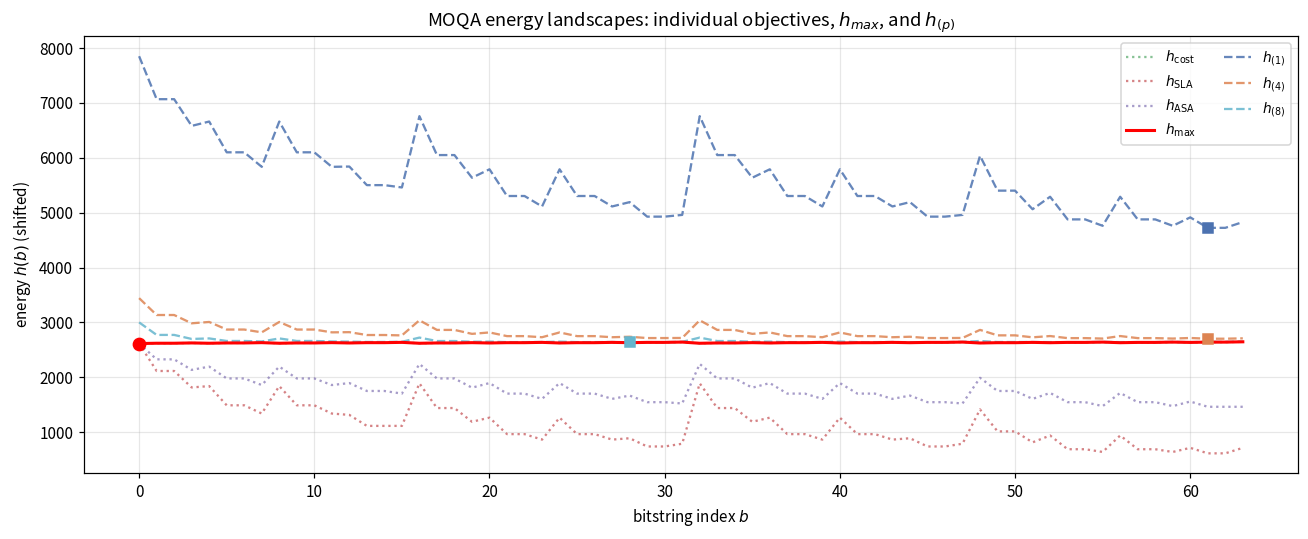

In [7]:

# Landscape plot: individual H_m (shifted) + h_max + selected h_(p)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(mqubo.ising_size)
colors_m = ["#55A868", "#C44E52", "#8172B2"]
for i, (q, lab, c) in enumerate(zip(mqubo.qubos_list, labels, colors_m)):
    ax.plot(x, q.H + mqubo.shift, ":", color=c, alpha=0.7, label=lab)
ax.plot(x, hmax_vec, "-", color="red", lw=2, label=r"$h_{\max}$", zorder=3)
ax.plot(hmax_arg, hmax_min, "o", color="red", ms=8, zorder=5)

# show p=1,4,8
for p_idx, color in [(0, "#4C72B0"), (3, "#DD8452"), (7, "#64B5CD")]:
    hp = mqubo.h_p_list[p_idx]
    ax.plot(x, hp[0], "--", color=color, alpha=0.85, label=fr"$h_{{({p_idx+1})}}$")
    ax.plot(hp[2], hp[1], "s", color=color, ms=6, zorder=4)

ax.set_xlabel(r"bitstring index $b$")
ax.set_ylabel(r"energy $h(b)$ (shifted)")
ax.set_title("MOQA energy landscapes: individual objectives, $h_{max}$, and $h_{(p)}$")
ax.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()


## 6. Hierarchy table + service evaluation of each $h_{(p)}$ ground state

In [8]:

rows = []
for i, hp in enumerate(mqubo.h_p_list):
    p = i + 1
    n_p = spins_to_n(hp[3])
    ev = evaluate_n(n_p, demand, R_sla, R_asa)
    same = (hp[2] == hmax_arg)
    hmax_at = float(hmax_vec[hp[2]])
    rel = abs(hmax_at - hmax_min) / max(abs(hmax_min), 1e-9)
    rows.append(dict(
        p=p, same_GS=same, n=str(n_p.tolist()), cost=ev["cost"],
        SLA=ev["sla"], ASA=ev["asa"], both=ev["meets_both"],
        short_SLA=ev["short_sla"], short_ASA=ev["short_asa"], rel_err=rel,
        agents=ev["agents"],
    ))
hdf = pd.DataFrame(rows)
display(hdf)

print(f"Exact h_max GS recovered: {hdf['same_GS'].sum()}/8 p-values")
print(f"Dual-feasible (SLA+ASA):  {hdf['both'].sum()}/8 p-values")


,p,same_GS,n,cost,SLA,ASA,both,short_SLA,short_ASA,rel_err,agents
0,1,False,"[2, 2, 1]",5.20,0.831412,130.611828,False,2.0,5.0,0.009936,5
1,2,False,"[2, 2, 1]",5.20,0.831412,130.611828,False,2.0,5.0,0.009936,5
2,3,False,"[2, 2, 1]",5.20,0.831412,130.611828,False,2.0,5.0,0.009936,5
3,4,False,"[2, 2, 1]",5.20,0.831412,130.611828,False,2.0,5.0,0.009936,5
4,5,False,"[2, 2, 1]",5.20,0.831412,130.611828,False,2.0,5.0,0.009936,5
5,6,False,"[2, 1, 1]",4.15,0.598208,295.280474,False,6.0,9.0,0.007930,4
6,7,False,"[2, 1, 1]",4.15,0.598208,295.280474,False,6.0,9.0,0.007930,4
7,8,False,"[1, 2, 0]",3.10,0.456822,388.293997,False,10.0,13.0,0.005923,3


Exact h_max GS recovered: 0/8 p-values
Dual-feasible (SLA+ASA):  0/8 p-values


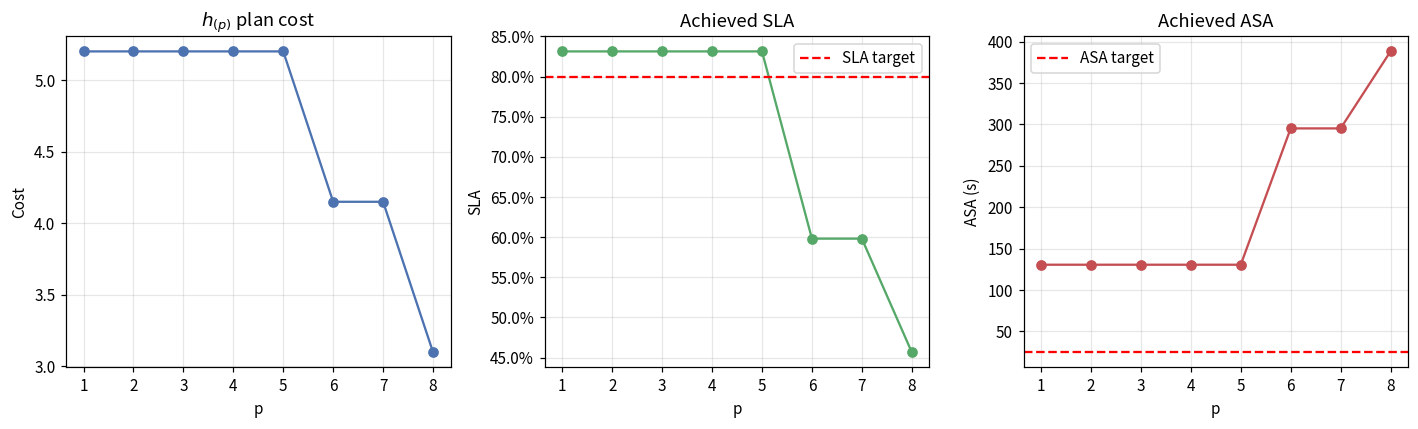

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ps = hdf["p"].values
axes[0].plot(ps, hdf["cost"], "o-", color="#4C72B0")
axes[0].set_xlabel("p"); axes[0].set_ylabel("Cost"); axes[0].set_title(r"$h_{(p)}$ plan cost")
axes[0].set_xticks(ps)

axes[1].plot(ps, hdf["SLA"], "o-", color="#55A868")
axes[1].axhline(TARGET_SL, color="red", ls="--", label="SLA target")
axes[1].set_xlabel("p"); axes[1].set_ylabel("SLA"); axes[1].set_title("Achieved SLA")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(); axes[1].set_xticks(ps)

axes[2].plot(ps, hdf["ASA"], "o-", color="#C44E52")
axes[2].axhline(TARGET_ASA, color="red", ls="--", label="ASA target")
axes[2].set_xlabel("p"); axes[2].set_ylabel("ASA (s)"); axes[2].set_title("Achieved ASA")
axes[2].legend(); axes[2].set_xticks(ps)
plt.tight_layout(); plt.show()



## 7. Brute-force dual-feasible optimum (reference) + best MOQA plan


In [10]:

best_bf = None
for bits in product([0, 1], repeat=N_SHIFTS*NMAX):
    n = np.zeros(N_SHIFTS, dtype=int)
    for s in range(N_SHIFTS):
        n[s] = sum(bits[s*NMAX:(s+1)*NMAX])
    ev = evaluate_n(n, demand, R_sla, R_asa)
    if not ev["meets_both"]:
        continue
    if best_bf is None or ev["cost"] < best_bf["cost"]:
        best_bf = ev

if best_bf:
    print(f"Brute-force dual-feasible min-cost: n={best_bf['n']} cost={best_bf['cost']:.2f} "
          f"SLA={best_bf['sla']:.1%} ASA={best_bf['asa']:.1f}s")
else:
    print("No dual-feasible plan in this encoding.")

# Best MOQA plan among hierarchy by dual-feasibility then cost
moqa_ok = [r for r in rows if r["both"]]
if moqa_ok:
    best_m = min(moqa_ok, key=lambda r: r["cost"])
    print(f"Best dual-feasible h_(p): p={best_m['p']} n={best_m['n']} cost={best_m['cost']:.2f}")
else:
    # pick lowest shortfall then cost
    best_m = min(rows, key=lambda r: (r["short_SLA"]+r["short_ASA"], r["cost"]))
    print(f"No dual-feasible h_(p) GS; best effort p={best_m['p']} n={best_m['n']} "
          f"SLA={best_m['SLA']:.1%} ASA={best_m['ASA']:.1f}s")


Brute-force dual-feasible min-cost: n=[2, 2, 2] cost=6.30 SLA=90.8% ASA=23.5s
No dual-feasible h_(p) GS; best effort p=1 n=[2, 2, 1] SLA=83.1% ASA=130.6s


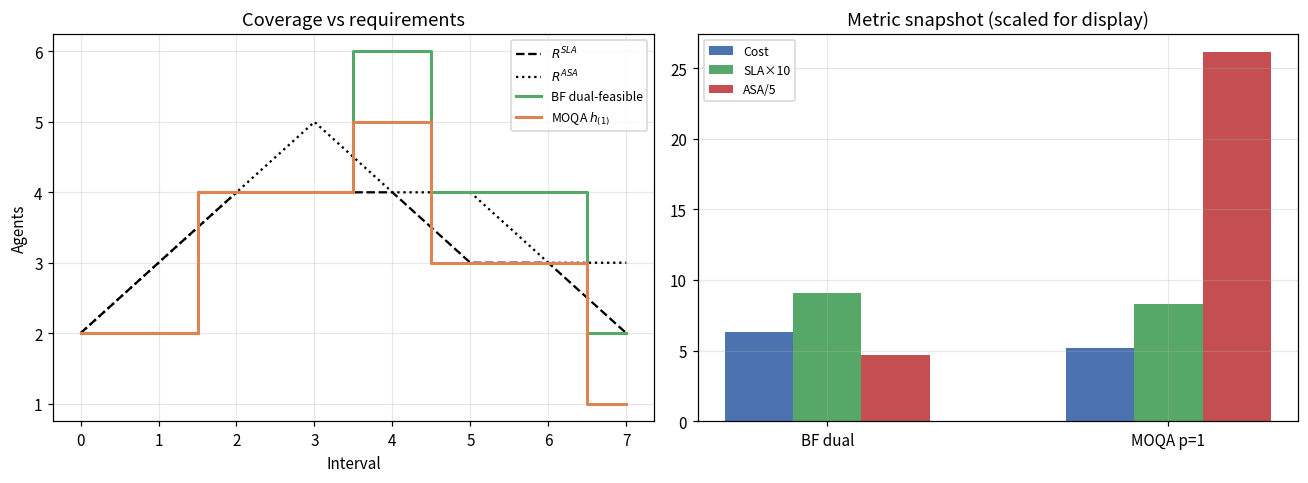

In [11]:

# Coverage comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(demand))
axes[0].plot(x, R_sla, "k--", lw=1.5, label=r"$R^{SLA}$")
axes[0].plot(x, R_asa, "k:", lw=1.5, label=r"$R^{ASA}$")
if best_bf:
    axes[0].step(x, best_bf["coverage"], where="mid", color="#55A868", lw=2, label="BF dual-feasible")
# MOQA best effort / dual
n_m = eval(best_m["n"]) if isinstance(best_m["n"], str) else best_m["n"]
ev_m = evaluate_n(n_m, demand, R_sla, R_asa)
axes[0].step(x, ev_m["coverage"], where="mid", color="#DD8452", lw=2, label=fr"MOQA $h_{{({best_m['p']})}}$")
axes[0].set_title("Coverage vs requirements"); axes[0].set_xlabel("Interval")
axes[0].set_ylabel("Agents"); axes[0].legend(fontsize=8)

# Bar comparison metrics
methods = []
costs, slas, asas = [], [], []
if best_bf:
    methods.append("BF dual")
    costs.append(best_bf["cost"]); slas.append(best_bf["sla"]); asas.append(best_bf["asa"])
methods.append(fr"MOQA p={best_m['p']}")
costs.append(best_m["cost"]); slas.append(best_m["SLA"]); asas.append(best_m["ASA"])

xx = np.arange(len(methods))
axes[1].bar(xx - 0.2, costs, 0.2, label="Cost", color="#4C72B0")
axes[1].bar(xx, [s*10 for s in slas], 0.2, label="SLA×10", color="#55A868")
axes[1].bar(xx + 0.2, [a/5 for a in asas], 0.2, label="ASA/5", color="#C44E52")
axes[1].set_xticks(xx); axes[1].set_xticklabels(methods)
axes[1].set_title("Metric snapshot (scaled for display)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()



## 8. Constrained-style view: weighted single objective vs \(h_{\max}\)

For the official score (SLA ≥ target, then min cost), a **weighted sum**
\(h = h_{\mathrm{cost}}+\lambda_{\mathrm{SLA}}h_{\mathrm{SLA}}+\lambda_{\mathrm{ASA}}h_{\mathrm{ASA}}\)
is often more direct. Below we compare its ground state to \(h_{\max}\).


Weighted-sum GS: n=[2, 2, 1] cost=5.20 SLA=83.1% ASA=130.6s both=False


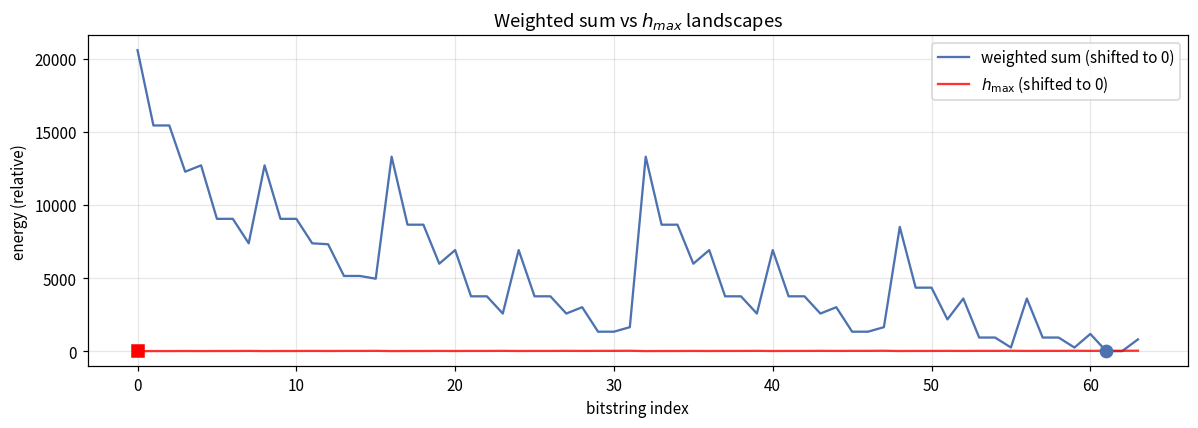

In [12]:

# Weighted-sum Ising = sum of shifted individual H (approximate scalarization)
H_weighted = (qubos[0].H + 8.0*qubos[1].H + 4.0*qubos[2].H)
w_arg = int(np.argmin(H_weighted))
n_w = spins_to_n(index_to_s(w_arg, N_SHIFTS*NMAX))
ev_w = evaluate_n(n_w, demand, R_sla, R_asa)
print(f"Weighted-sum GS: n={n_w.tolist()} cost={ev_w['cost']:.2f} "
      f"SLA={ev_w['sla']:.1%} ASA={ev_w['asa']:.1f}s both={ev_w['meets_both']}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(H_weighted - H_weighted.min(), label="weighted sum (shifted to 0)", color="#4C72B0")
ax.plot(hmax_vec - hmax_min, label=r"$h_{\max}$ (shifted to 0)", color="red", alpha=0.8)
ax.plot(w_arg, 0, "o", color="#4C72B0", ms=8)
ax.plot(hmax_arg, 0, "s", color="red", ms=8)
ax.set_xlabel("bitstring index"); ax.set_ylabel("energy (relative)")
ax.set_title("Weighted sum vs $h_{max}$ landscapes"); ax.legend()
plt.tight_layout(); plt.show()



## 9. Summary & how to plug into QAOA

**MOQA role:** build a multi-objective / constrained Hamiltonian \(\hat H^{(p)}\).

**Quantum search role:** find its ground state with LR-QAOA / QAOA sampling (as in the dual-target notebook).

| Piece | Status in this notebook |
|-------|-------------------------|
| Dual \(R^{\mathrm{SLA}}, R^{\mathrm{ASA}}\) | Done |
| \(M=3\) QUBOs + Ising | Done |
| \(h_{\max}\), \(h_{(p)}\) hierarchy | Done |
| Landscape & metric plots | Done |
| Brute-force dual-feasible reference | Done |
| Hand \(\hat H^{(p)}\) to LR-QAOA | Next step (reuse prior QAOA sampler) |

**Takeaway:** MOQA gives a principled multi-objective Hamiltonian for cost vs SLA vs ASA.
For the challenge score (SLA ≥ target → min cost), scalarized dual-\(R\) QUBO + LR-QAOA remains the most direct path; MOQA is preferred when you want multi-objective approximation theory and a hierarchy in \(p\).


In [13]:

out = dict(
    demand=demand.tolist(), R_sla=R_sla.tolist(), R_asa=R_asa.tolist(),
    hmax=dict(index=hmax_arg, n=n_hmax.tolist(), **{k: ev_hmax[k] for k in
              ["cost","sla","asa","meets_both","agents"]}),
    hierarchy=rows,
    brute_force_dual=best_bf,
    weighted_sum=dict(n=n_w.tolist(), **{k: ev_w[k] for k in
                     ["cost","sla","asa","meets_both","agents"]}),
    method="MOQA h_max / h_(p) on cost + SLA shortfall + ASA shortfall QUBOs",
)
os.makedirs("/home/workdir/artifacts/callcenter/moqa", exist_ok=True)
path = "/home/workdir/artifacts/callcenter/moqa/moqa_notebook_results.json"
with open(path, "w") as f:
    json.dump(out, f, indent=2, default=str)
print("Saved", path)
print("DONE.")


Saved /home/workdir/artifacts/callcenter/moqa/moqa_notebook_results.json
DONE.
